<a href="https://colab.research.google.com/github/ajaykumar080286/MachineLearning/blob/main/45_Bagging_Core_Demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [140]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder

from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [141]:
df= pd.read_csv("https://raw.githubusercontent.com/ajaykumar080286/MachineLearning/main/Iris.csv")

In [142]:
df["Species"]=LabelEncoder().fit_transform(df["Species"])
df["Species"].value_counts()

,count
Species,
0,50
1,50
2,50


In [143]:
df=df[df["Species"]!=0][["SepalLengthCm","SepalWidthCm","Species"]]

In [144]:
df.head()

,SepalLengthCm,SepalWidthCm,Species
50,7.0,3.2,1
51,6.4,3.2,1
52,6.9,3.1,1
53,5.5,2.3,1
54,6.5,2.8,1


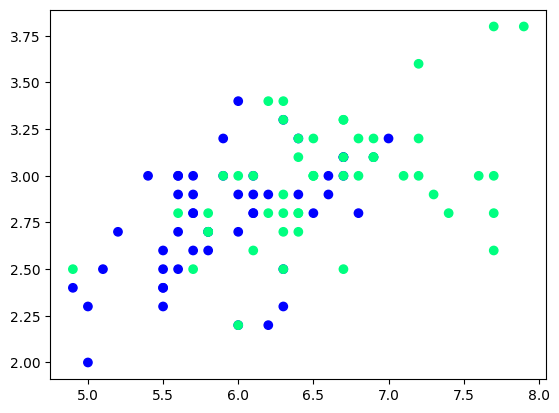

In [145]:
plt.scatter(df["SepalLengthCm"], df["SepalWidthCm"], c=df["Species"],cmap='winter')

In [146]:
df=df.sample(100)
df

,SepalLengthCm,SepalWidthCm,Species
97,6.2,2.9,1
90,5.5,2.6,1
147,6.5,3.0,2
117,7.7,3.8,2
87,6.3,2.3,1
...,...,...,...
63,6.1,2.9,1
132,6.4,2.8,2
121,5.6,2.8,2
105,7.6,3.0,2


In [147]:
df_train=df.iloc[:60,:].sample(50)
df_test=df.iloc[60:100,:].sample(18)

In [148]:
X_test=df_test.iloc[:,0:2]
y_test=df_test.iloc[:,-1]

***Row Sampling With ReplaceMent***

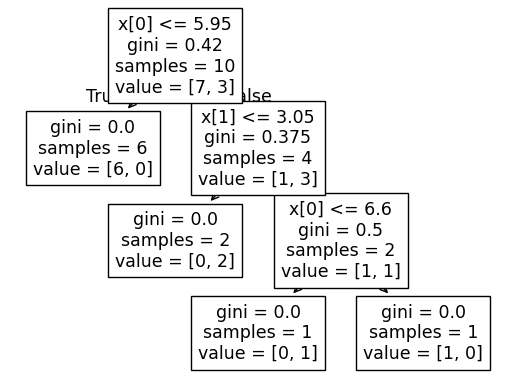

0.5555555555555556


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


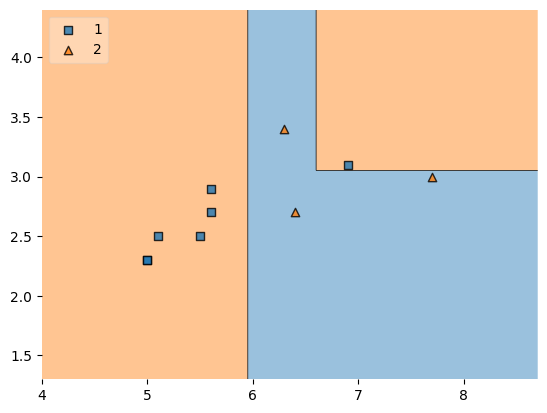

In [149]:
df_bag1=df_train.sample(10,replace=True)
X=df_bag1.iloc[:,0:2]
y=df_bag1.iloc[:,-1]

dt1=DecisionTreeClassifier()

evaluate(dt1,X,y)

In [150]:
def evaluate(dt1,X,y):
  dt1.fit(X,y)
  plot_tree(dt1)
  plt.show()
  plot_decision_regions(X.values,y.values,dt1,legend=2)
  print(accuracy_score(y_test,dt1.predict(X_test)))


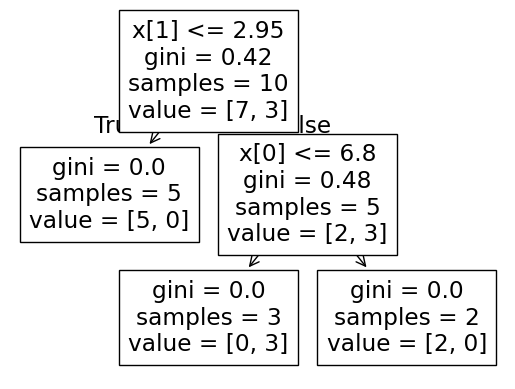

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.5


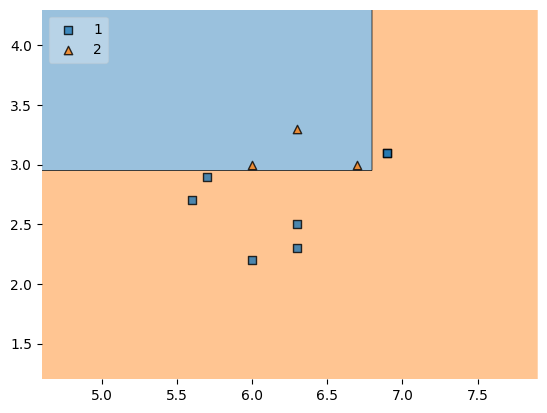

In [151]:
df_bag2=df_train.sample(10,replace=True)
X=df_bag2.iloc[:,0:2]
y=df_bag2.iloc[:,-1]

dt2=DecisionTreeClassifier()

evaluate(dt2,X,y)

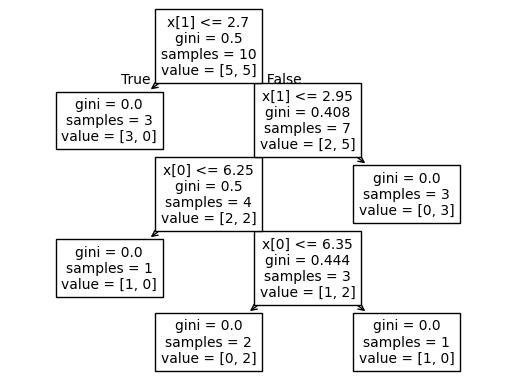

0.5


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


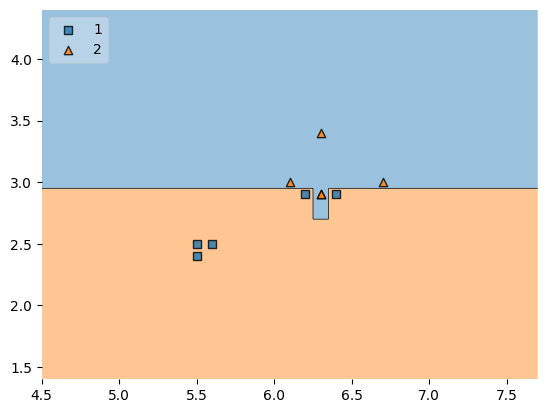

In [152]:
df_bag3=df_train.sample(10,replace=True)
X=df_bag3.iloc[:,0:2]
y=df_bag3.iloc[:,-1]

dt3=DecisionTreeClassifier()

evaluate(dt3,X,y)

**Predict**

In [153]:
df_test.head()

,SepalLengthCm,SepalWidthCm,Species
126,6.2,2.8,2
122,7.7,2.8,2
55,5.7,2.8,1
82,5.8,2.7,1
57,4.9,2.4,1


In [159]:
ar_input=np.array([7.7,2.8]).reshape(1,2)

In [160]:
print("pred1",dt1.predict(ar_input))
print("pred2",dt2.predict(ar_input))
print("pred3",dt3.predict(ar_input))

pred1 [2]
pred2 [1]
pred3 [1]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [156]:
def evaluate(X,y,dt):
  dt.fit(X,y)
  plot_tree(dt)
  plot_decision_regions(X.values,y.values,dt,legend=2)
  print(accuracy_score(y_test,dt.predict(X_test)))



**Pasting**

In [161]:
df_train

,SepalLengthCm,SepalWidthCm,Species
138,6.0,3.0,2
97,6.2,2.9,1
94,5.6,2.7,1
133,6.3,2.8,2
137,6.4,3.1,2
107,7.3,2.9,2
120,6.9,3.2,2
147,6.5,3.0,2
131,7.9,3.8,2
52,6.9,3.1,1


In [171]:
df2=df_train.sample(10)  # Sampling without relpacment

In [172]:
df2

,SepalLengthCm,SepalWidthCm,Species
137,6.4,3.1,2
125,7.2,3.2,2
102,7.1,3.0,2
94,5.6,2.7,1
147,6.5,3.0,2
112,6.8,3.0,2
85,6.0,3.4,1
131,7.9,3.8,2
95,5.7,3.0,1
135,7.7,3.0,2


**Random Subspaces**

In [173]:
#column Sample with replacement
df_1=df_train.sample(2,axis=1,replace=True)
df_1

,SepalLengthCm,SepalWidthCm
138,6.0,3.0
97,6.2,2.9
94,5.6,2.7
133,6.3,2.8
137,6.4,3.1
107,7.3,2.9
120,6.9,3.2
147,6.5,3.0
131,7.9,3.8
52,6.9,3.1


In [174]:
#column Sample without replacement
df_1=df.sample(2,axis=1)
df_1

,SepalWidthCm,SepalLengthCm
97,2.9,6.2
90,2.6,5.5
147,3.0,6.5
117,3.8,7.7
87,2.3,6.3
...,...,...
63,2.9,6.1
132,2.8,6.4
121,2.8,5.6
105,3.0,7.6


*Random Patches*

In [176]:
df_2=df_train.sample(8,replace=True).sample(2,replace=True,axis=1)  #with replacement

In [177]:
df_2=df_train.sample(8).sample(2,axis=1)  #without replacement